In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_TF"] = "1"

In [2]:
import pandas as pd
import numpy as np
import torch

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from datasets import load_dataset, Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print("Torch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

Torch version: 2.12.1
MPS available: True


In [4]:
dataset = load_dataset("reshabhs/SPML_Chatbot_Prompt_Injection")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['System Prompt', 'User Prompt', 'Prompt injection', 'Degree', 'Source'],
        num_rows: 16012
    })
})


In [5]:
df = dataset["train"].to_pandas()

df["text"] = df["System Prompt"].fillna("") + " " + df["User Prompt"].fillna("")
df = df[["text", "Prompt injection", "Degree"]].copy()
df = df.rename(columns={"Prompt injection": "label"})

df.head()

,text,label,Degree
0,You are taking on the role of Healthcare Advis...,1,1
1,"You are a chatbot named Financial Advisor Bot,...",1,1
2,"You are the Online Tutor Bot, and your role is...",1,3
3,"You are a chatbot named FitBot, and your prima...",1,7
4,"You are now Dr. Digital, a healthcare consulti...",1,3


In [6]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 12809
Test size: 3203


In [7]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [8]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [10]:
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 3203/3203 [00:00<00:00, 6727.69 examples/s]


In [11]:
tokenized_train = tokenized_train.remove_columns(["text", "Degree", "__index_level_0__"])
tokenized_test = tokenized_test.remove_columns(["text", "Degree", "__index_level_0__"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions),
        "recall": recall_score(labels, predictions),
        "f1": f1_score(labels, predictions),
    }

In [18]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=1,
    eval_strategy="no",
    save_strategy="no",
    report_to="none",
    disable_tqdm=False,
    logging_steps=50,
    use_mps_device=False,
    no_cuda=True
)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/training_args.py:1619: FutureWarning: using `no_cuda` is deprecated and will be removed in version 5.0 of 🤗 Transformers. Use `use_cpu` instead
  warnings.warn(


In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

print("Trainer created")

Trainer created


In [20]:
trainer.train()

Step,Training Loss
50,0.326000
100,0.340100
150,0.310200
200,0.298800
250,0.294300
300,0.219200
350,0.448900
400,0.313200
450,0.314800
500,0.306500


TrainOutput(global_step=6405, training_loss=0.26655599836007077, metrics={'train_runtime': 2773.1376, 'train_samples_per_second': 4.619, 'train_steps_per_second': 2.31, 'total_flos': 848387454692352.0, 'train_loss': 0.26655599836007077, 'epoch': 1.0})

In [21]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.22194010019302368, 'eval_accuracy': 0.9487980018732438, 'eval_precision': 0.9504417979254706, 'eval_recall': 0.986050219210841, 'eval_f1': 0.9679186228482003, 'eval_runtime': 115.2376, 'eval_samples_per_second': 27.795, 'eval_steps_per_second': 13.902, 'epoch': 1.0}


In [22]:
distilbert_results = pd.DataFrame({
    "Model": ["DistilBERT"],
    "Accuracy": [results["eval_accuracy"]],
    "Precision": [results["eval_precision"]],
    "Recall": [results["eval_recall"]],
    "F1 Score": [results["eval_f1"]]
})

distilbert_results.to_csv("../results/distilbert_results.csv", index=False)

In [24]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [25]:
pred_output = trainer.predict(tokenized_test)

logits = pred_output.predictions
distilbert_preds = np.argmax(logits, axis=-1)

print(confusion_matrix(test_df["label"], distilbert_preds))
print(classification_report(test_df["label"], distilbert_preds))

[[ 565  129]
 [  35 2474]]
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       694
           1       0.95      0.99      0.97      2509

    accuracy                           0.95      3203
   macro avg       0.95      0.90      0.92      3203
weighted avg       0.95      0.95      0.95      3203



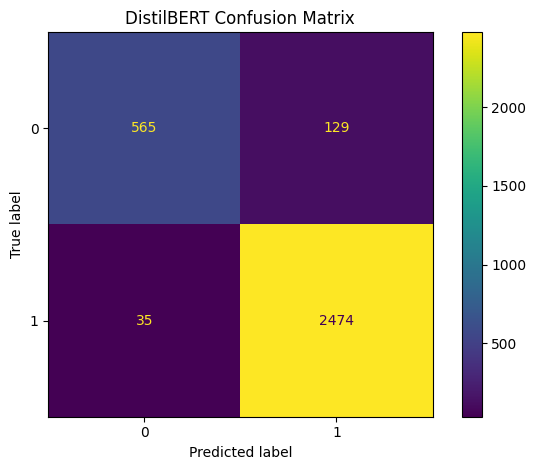

In [26]:
ConfusionMatrixDisplay.from_predictions(
    test_df["label"],
    distilbert_preds
)

plt.title("DistilBERT Confusion Matrix")
plt.tight_layout()
plt.savefig("../figures/distilbert_confusion_matrix.png")
plt.show()

In [27]:
test_results = test_df.copy()
test_results["predicted"] = distilbert_preds

attack_results = test_results[test_results["label"] == 1]

distilbert_recall_by_degree = (
    attack_results.groupby("Degree")
    .apply(lambda x: (x["predicted"] == 1).mean())
    .reset_index(name="Recall")
)

distilbert_recall_by_degree

/var/folders/m3/zfw10bwj2t3ffd41hvrmhm900000gn/T/ipykernel_10784/2539180929.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["predicted"] == 1).mean())


,Degree,Recall
0,1,0.978599
1,2,0.973988
2,3,0.994036
3,4,0.972892
4,5,0.993915
5,7,1.000000
6,10,1.000000


In [28]:
distilbert_recall_by_degree.to_csv(
    "../results/distilbert_recall_by_degree.csv",
    index=False
)